# Lab 9

In [11]:
### MATPLOTLIB SETUP ###
import math
from math import sqrt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import curve_fit
from scipy import signal
import sys
pd.set_option('display.float_format', lambda x: '%e' % x)

## Amit's library with some utility functions for reading and processing scope data; reproduced below
sys.path.append("../../")
from lib import *

from rich.console import Console
from rich.syntax import Syntax
Console().print(Syntax.from_path("../../lib.py", line_numbers=True, theme="monokai"))

## Jupyter magic
%matplotlib
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

    1 import csv                                                                                                   
    2 import pandas as pd                                                                                          
    3 import numpy as np                                                                                           
    4 from scipy.signal import find_peaks                                                                          
    5                                                                                                              
    6 R = 5 # Load Resistance                                                                                      
    7 VG = 18 # Input Voltage                                                                                      
    8 Fs = 50500 # Measured frequency                                                                              
    9 Ts = 1/ Fs                                                                                                   
   10 R_SHUNT = 0.05 # from schematic                                                                              
   11                                                                                                              
   12 # read funky Rigol CSV format                                                                                
   13 def read_rigol_csv(csv_file_name):                                                                           
   14     with open(csv_file_name) as f:                                                                           
   15         rows = list(csv.reader(f))                                                                           
   16         i = 0                                                                                                
   17         while rows[0][i] != "":                                                                              
   18             i = i+1                                                                                          
   19         numcols = i-2                                                                                        
   20         t0 = float(rows[1][numcols])                                                                         
   21         dT = float(rows[1][numcols+1])                                                                       
   22                                                                                                              
   23     data = pd.read_csv(csv_file_name, usecols=range(0,numcols), skiprows=[1])                                
   24     data['X'] = t0+data['X']*dT                                                                              
   25     return data, t0, dT                                                                                      
   26                                                                                                              
   27 def import_and_clean(name, cols, filt, filt_len=10):                                                         
   28     """                                                                                                      
   29     Import and clean some data from the Rigol scope                                                          
   30                                                                                                              
   31     @param name: name of csv file (assumed to live in `./data`)                                              
   32     @param cols: what to rename columns to                                                                   
   33     @param filt: whether to

Using matplotlib backend: ipympl
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Q1

The below cell plots our measurement taken with a 10.5V output at DC offset of 2.3V on our waveform generator

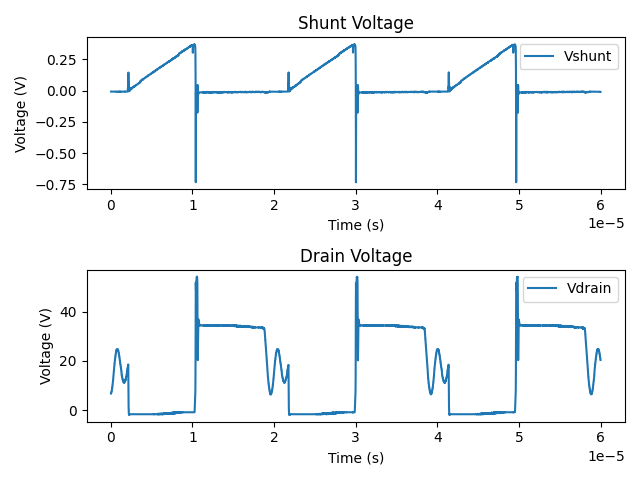

In [2]:
q1, _ = import_and_clean("baseline", ["Vshunt", "Vdrain"], True)
figure, (ax1, ax2) = plt.subplots(2,1)
q1.plot(x="X", y="Vshunt", ax=ax1, title="Shunt Voltage")
q1.plot(x="X", y="Vdrain", ax=ax2, title="Drain Voltage")

ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Voltage (V)")
figure.tight_layout()

The table below lists our output voltages and peak currents stepping the DC offset from 1.5V all the way to this 2.3V value

| V Comp Offset (V) | V Out (V) | I pk (A) |
| ----------------- | --------- | -------- |
| 1.5               | 3.4       | 2.2      |
| 1.6               | 4.3       | 2.88     |
| 1.7               | 5.2       | 3.56     |
| 1.8               | 6.1       | 4.12     |
| 1.9               | 7         | 4.76     |
| 2.0               | 7.89      | 5.4      |
| 2.1               | 8.76      | 6.04     |
| 2.2               | 9.66      | 6.68     |
| 2.3               | 10.51     | 7.32     |

Ipk was calculated by dividing the max shunt voltage (found with our scope cursor) by the shunt resistance of 0.05 ohms.

### Q2

While doing our small signal amplitude, the LED appears to be blinking or flickering because as peak current control is oscillating, the output is also oscillating with it. This corresponds to an increasing and decreasing LED brightness, and at low enough frequencies this variation is visible to the naked eye.

### Q3

First, I plotted by Voffset and Ipk findings from the DC bias portion of the lab. Noticing the relationship appears to be linear, I found a line of best fit using numpy with an equation of:

$$
I_{pk} = 6.35 * V_{offset} -7.298
$$

Ipk = 6.35333333333333 * V_offset + -7.297999999999994


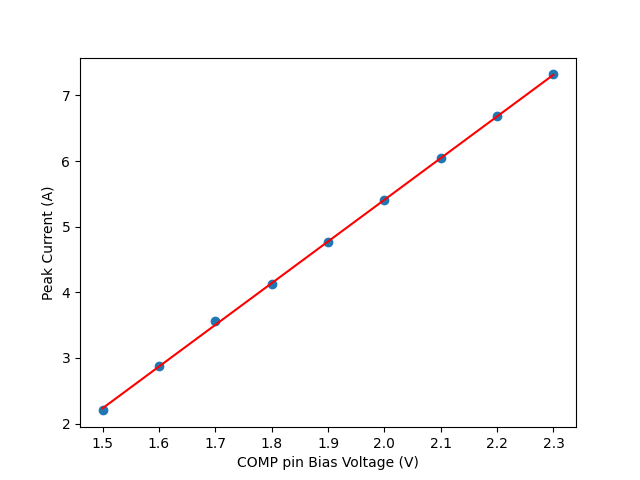

In [3]:
dc_offset = [1.5, 1.6, 1.7, 1.8, 1.9, 2, 2.1, 2.2, 2.3]
dc_vout = [3.4, 4.3, 5.2, 6.1, 7, 7.89, 8.76, 9.66, 10.51]
dc_ipk = [2.2, 2.88, 3.56, 4.12, 4.76, 5.4, 6.04, 6.68, 7.32]

m, b = np.polyfit(dc_offset, dc_ipk, 1)
print(f"Ipk = {m} * V_offset + {b}")

plt.figure()
plt.xlabel("COMP pin Bias Voltage (V)")
plt.ylabel("Peak Current (A)")
plt.scatter(dc_offset, dc_ipk)
plt.plot(dc_offset, np.array(dc_offset) * m + b, color='red')
plt.show()

### Q4/5

The COMP voltage enters the UC2844 chip and gets dropped somewhat over 2 diodes, then is further divided by 3 by the resistor network. Thie value is then compared to the primary shunt measurement, and when the current meets this value, the gate toggles off. We know current is proportional to voltage by Ohm's law, so the line found in the previous part makes sense here.

If we were to ignore the two diodes for a moment, we could say something like:
$$
I_{pk} = \frac{V_{comp}}{3 \cdot 0.05\Omega}
$$

Plotting this over our previous plot gives the green line below, which seems to have a similar slope (6.66) to the fitted line, with the remaining downward shift probably being from the diodes

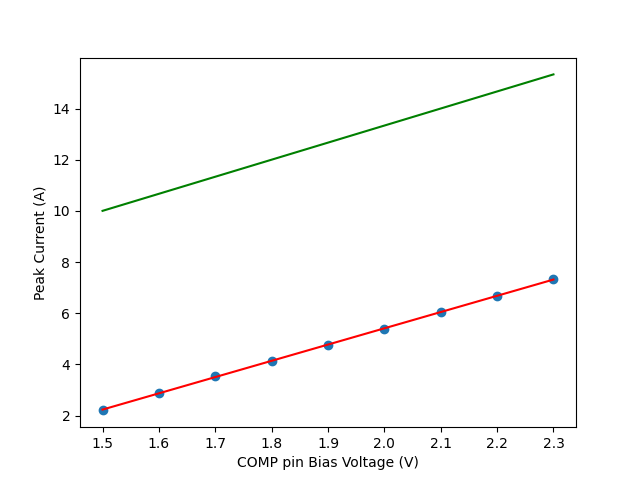

In [4]:
plt.plot(dc_offset, np.array(dc_offset)/0.15, color='green')
plt.show()

### Q6

First, I plotted by Voffset and Vout findings from the DC bias portion of the lab. 

$$
V_{out} = 8.9 * V_{offset} -9.94
$$

Vout = 8.904999999999994 * V_offset + -9.939499999999986


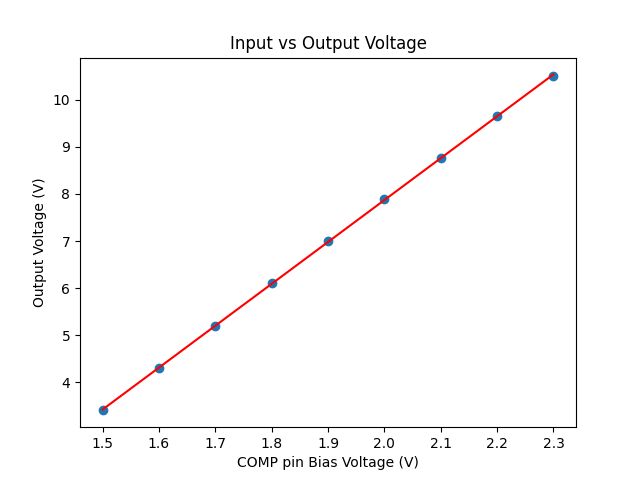

In [5]:
dc_offset = [1.5, 1.6, 1.7, 1.8, 1.9, 2, 2.1, 2.2, 2.3]
dc_vout = [3.4, 4.3, 5.2, 6.1, 7, 7.89, 8.76, 9.66, 10.51]
dc_ipk = [2.2, 2.88, 3.56, 4.12, 4.76, 5.4, 6.04, 6.68, 7.32]

m, b = np.polyfit(dc_offset, dc_vout, 1)
print(f"Vout = {m} * V_offset + {b}")

plt.figure()
plt.title("Input vs Output Voltage")
plt.xlabel("COMP pin Bias Voltage (V)")
plt.ylabel("Output Voltage (V)")
plt.scatter(dc_offset, dc_vout)
plt.plot(dc_offset, np.array(dc_offset) * m + b, color='red')
plt.show()

### Q7/Q8

Looking at the flyback lecture notes, I found the equation

$$
I_{pk} = \sqrt{\Kappa} \cdot T_s \cdot * \frac{V}{L}
$$

where 

$$
\Kappa = \frac{2}{T_s} \frac{L}{R \cdot a^2}
$$

We can rearrange the first equation, since we know peak current from the previous part and want to find output voltage. Note that we also divide the final result by our turns ratio, since we want to apply a buck-boost equation to our flyback converter, as well as tranform the resistance in the Kappa equation

$$
V = \frac{I_{pk} \cdot L}{\sqrt{\Kappa} \cdot T_s \cdot a}
$$

Lastly, we can sub in our calcualated equation for Ipk from Vcomp to obtain this final equation

$$
V = \frac{(6.35 \cdot V_{comp} -7.298) \cdot L}{\sqrt{\Kappa} \cdot T_s \cdot a}
$$

The below code cell calculates this value and plots it by our measured data.

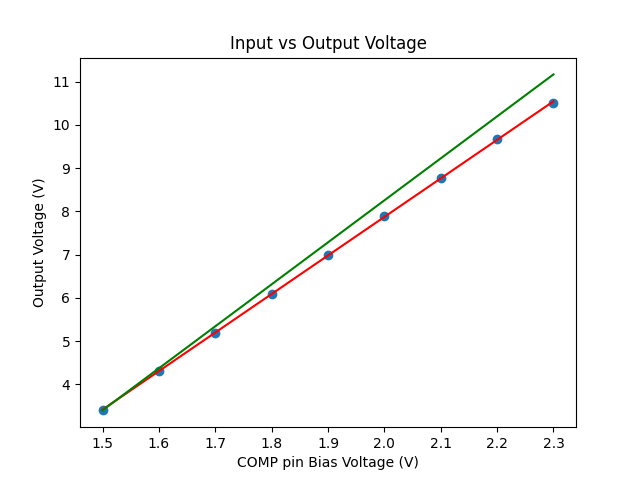

In [6]:
L = 18.49e-6
a = 0.63

K = (2/Ts) * (L/(R*a**2))
Ipk_calc = np.array(dc_offset) * 6.35 - 7.298
V = (Ipk_calc * L)/(np.sqrt(K) * Ts * a)

plt.plot(dc_offset, V, color='green')
plt.show()

This seems to be a fairly close match - the predicted value is slightly higher, particularly at higher voltages, which could potentially have to do with some of the inefficiency in our real converter.

### Q9

The below code cell plots our magnitude and phase for each voltage.


In [7]:
v15 = pd.read_csv("data/1.5v.csv")
v5 = pd.read_csv("data/5v.csv")
v7 = pd.read_csv("data/7v.csv")
v10 = pd.read_csv("data/10v.csv")

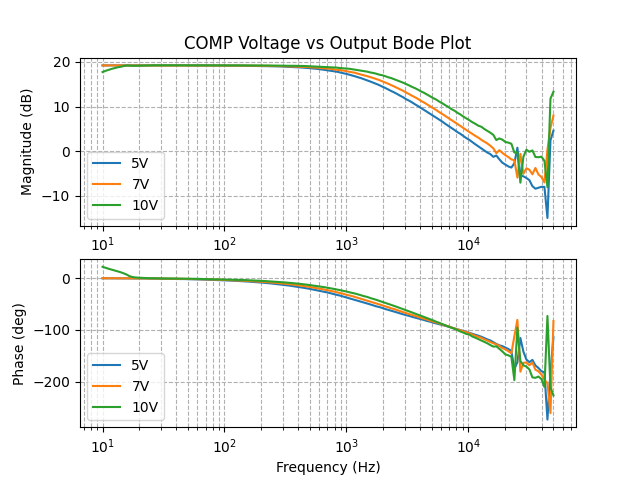

In [8]:
fig, (ax1, ax2) = plt.subplots(2,1)
names = ["5V", "7V", "10V"]
for df, name in zip([v5, v7, v10], names):
    freq = df["Frequency (Hz)"]
    mag = df["Channel 2 Magnitude (dB)"]
    phase = np.rad2deg(np.unwrap(np.deg2rad(df['Channel 2 Phase (deg)'])))
    ax1.plot(freq, mag)
    ax2.plot(freq, phase)

ax1.set_xscale("log")
ax2.set_xscale("log")
ax2.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (deg)")
ax1.set_title("COMP Voltage vs Output Bode Plot")
ax1.legend(names)
ax2.legend(names)
ax1.grid(True, which="both", ls="--")
ax2.grid(True, which="both", ls="--")


### Q10

All in all, the plots stay fairly similar as the output voltage changes. For the magnitude, all plots have roughly the same DC/low frequency gain (which the exception of 10V, which starts slightly lower), but when we reach the cutoff, the lower voltages roll off slightly quicker than the higher ones. Looking at the lecture notes, this would make the zero in our transfer function slightly larger.

The phases stay much closer in lockstep throughout the frequency range (with the 10V phase being slightly higher at the begining than the others.) 

### Q11

The DC gain is about 20 dB, which corresponds to a linear gain of about 10. In our line fit from Q9, we found the slope to be about 9 so this matches up fairly well (the small difference could be due to inefficiency).

### Q12

Looking at our graph and lecture notes, we can begin with a rudimentary model as a first order low pass filter.

$$
V(s) = \frac{V}{i_{pk}} \cdot \frac{1}{1+\frac{s}{\omega _0}} * i_{pk}(s)
$$

Taking the frequency to be $\frac{2}{RC}$ per the lecture notes, that gives us a transfer function of

$$
H(s) = 8.9 \cdot \frac{1}{1+\frac{RC}{2}s}
$$

Where 8.9 is our linear gain between Vcomp and Ipk. The below code cell creates and plots a bode plot of this function.

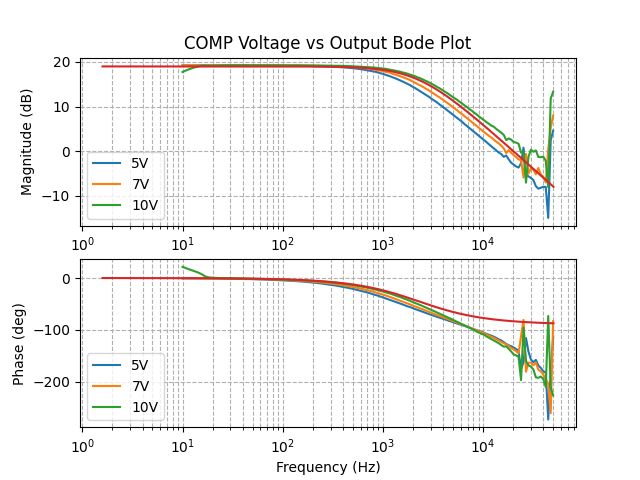

In [9]:
# plot old values

fig, (ax1, ax2) = plt.subplots(2,1)
names = ["5V", "7V", "10V"]
for df, name in zip([v5, v7, v10], names):
    freq = df["Frequency (Hz)"]
    mag = df["Channel 2 Magnitude (dB)"]
    phase = np.rad2deg(np.unwrap(np.deg2rad(df['Channel 2 Phase (deg)'])))
    ax1.plot(freq, mag)
    ax2.plot(freq, phase)

ax1.set_xscale("log")
ax2.set_xscale("log")
ax2.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Magnitude (dB)")
ax2.set_ylabel("Phase (deg)")
ax1.set_title("COMP Voltage vs Output Bode Plot")
ax1.legend(names)
ax2.legend(names)
ax1.grid(True, which="both", ls="--")
ax2.grid(True, which="both", ls="--")

K = 8.89
C = 28e-6 # with DC bias at 10V, output capacitance was measured at about 28uF in lab 5

numerator = [K]
denominator = [(R*C)/2, 1]  # Example: s^2 + 10s + 20
transfer_function = signal.TransferFunction(numerator, denominator)

# Generate the Bode plot data
w = np.logspace(1,5.5,1000)
w, mag, phase = signal.bode(transfer_function, w)

ax1.semilogx(w/(2*np.pi), mag)
ax2.semilogx(w/(2*np.pi), phase)

### Q13

In the transfer function from Q12, there's a real pole at -2/RC, or -2273 Hz. We want the cutoff at this point to filter out our switching frequency and reduce our ripple. In this case, our 50k switching frequency will be very well attenuated by this filter, but our DC output will not be affected.

In [10]:
-2/(R*C*2*np.pi)

-2273.6420441699333

### Q14

I do believe there are some other poles/zeroes in this function. Primarily, the phase plot clues me in that there is another pole, as the phase goes down to -180 degrees, and each pole only gives abut a 90 degree phase shift. However, there's also a clue tht there's another 0; at around 6000 Hz, we can see that the slope of the magnitude plot decreases (at different rates for each voltage), which indicates that there could also be a zero at this location.

Our lecture notes also seem to corroborate this, with one dominating pole, one second high-frequency pole, and one zero.

### Q15

The graph behavior starts to break down a bit past about 10000 Hz - there's a few reasons for this. First, our averaged model mainly tends to be accurate for frequencies below one fifth of the switching frequency per the lecture notes. Additionally, our sweep is also limited by the switching frequency, as otherwise we begin to introduce aliasing into our sample.

Additionally, I also noticed that as I change my output capacitnace to what I measured for the different voltages in lab 5 (which can vary as much as 25% due to DC Bias), the simulated bode plot closes matches that particular voltage waveform quite closely, which gives me some additional confidence that this transfer function is a decent approximation of our actual transfer function.